# 01 - Baseline CNN Model
## Project: Malaria Image Classification

This notebook implements a **baseline Convolutional Neural Network (CNN)** for binary classification of microscopic blood smear images.

The goal is to classify images as:
- **Parasitized** (infected with malaria parasites)
- **Uninfected** (healthy red blood cells)

---
## Dataset
We use the **NIH Malaria Dataset**, which contains segmented red blood cell images collected from thin blood smear slides.
- Total Images: ~27,000
- Classes: Parasitized / Uninfected
- Balanced dataset

Images are resized to **128 x 128 pixels** and normalized to improve training stability.

---
## Objective of This Notebook
This notebook establishes a **baseline CNN architecture built from scratch** to:
- Serve as a performance benchmark
- Provide a comparison point for transfer learning models (e.g., MobileNetV2)
- Analyze basic CNN behavior before fine-tuning pretrained networks

---

## Model Architecture (Baseline CNN)

The baseline CNN consists of:
- Convolutional layers with ReLU activation
- MaxPooling layers for spatial reduction
- Dropout for regularization
- Fully connected (Dense) layers
- Sigmoid output for binary classification

---

## Evaluation Metrics
We evaluate model performance using:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

---

## Expected Outcome
This baseline model provides a foundational performance reference.
More advanced models (transfer learning, fine-tuning, Grad-CAM analysis) will be implemented in subsequent notebooks.

## Import Required Libraries

In [3]:
# Data visualization and analytics
import matplotlib.pyplot as plt # Plot graphs and images
import numpy as np              # Handle arrays and numerical data
import seaborn as sns           # Generate heatmaps and styled plots

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# File and image processing
import os   # Work with file paths
import shutil  # File operations
import cv2  # Image loading and resizing

# TensorFlow / Keras modules for building CNN
from tensorflow.keras.preprocessing.image import ImageDataGenerator                # Image augmentation
from tensorflow.keras.models import Sequential                                     # Model type (sequential layers)
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # Layers for CNN
from tensorflow.keras.callbacks import EarlyStopping                               # Stop training early if overfitting

## Dataset Setup & Cleaning
In this section, we will download the Malaria Cell Images dataset directly from Kaggle into our Colab environment.
The dataset contains two categories of cell images:
*   Parasitized (Infected with Malaria)
*   Uninfected



In [4]:
RAW_DATA_DIR = "data/raw"
BASE_DIR = os.path.join(RAW_DATA_DIR, "cell_images") # Where Kaggle dataset is unzipped
CLEAN_DIR = os.path.join(RAW_DATA_DIR, "clean_cell_images") # Clean folder for training

# Make sure raw folder exists
os.makedirs(RAW_DATA_DIR, exist_ok=True)

# Set Kaggle config directory to current folder
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()

# Check for kaggle.json (you need to upload it in Colab first)
if not os.path.exists('kaggle.json'):
    raise FileNotFoundError("Kaggle API token file 'kaggle.json' not found. Please upload it to the current directory.")

# Download & unzip dataset **only if it doesn't exist**
if not os.path.exists(BASE_DIR):
    !kaggle datasets download -d 'iarunava/cell-images-for-detecting-malaria' -p {RAW_DATA_DIR} --unzip
else:
    print("Dataset already downloaded and unzipped.")

# Detect whether there is a nested cell_images folder
if os.path.exists(os.path.join(BASE_DIR, "cell_images")):
  # Nested case: cell_images/cell_images/Parasitized
  DATA_SOURCE_DIR = os.path.join(BASE_DIR, "cell_images")
else:
  # Normal case: cell_images/Parasitized
  DATA_SOURCE_DIR = BASE_DIR

print("Using data source dictionary:", DATA_SOURCE_DIR)

# Remove old clean folder if it exists
if os.path.exists(CLEAN_DIR):
  shutil.rmtree(CLEAN_DIR)

# Copy clean structure
shutil.copytree(
    os.path.join(DATA_SOURCE_DIR, "Parasitized"),
    os.path.join(CLEAN_DIR, "Parasitized")
)

shutil.copytree(
    os.path.join(DATA_SOURCE_DIR, "Uninfected"),
    os.path.join(CLEAN_DIR, "Uninfected")
)

print("Clean dataset ready at:", CLEAN_DIR)

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 98% 661M/675M [00:00<00:00, 1.73GB/s]
100% 675M/675M [00:00<00:00, 1.73GB/s]
Using data source dictionary: data/raw/cell_images/cell_images
Clean dataset ready at: data/raw/clean_cell_images


## Data Exploration
In this section, we will:
1.   List all images in the Parasitized and Uninfected folders
2.   Display example images to understand the dataset



Number of Parasitized images: 13780
Number of Uninfected images: 13780


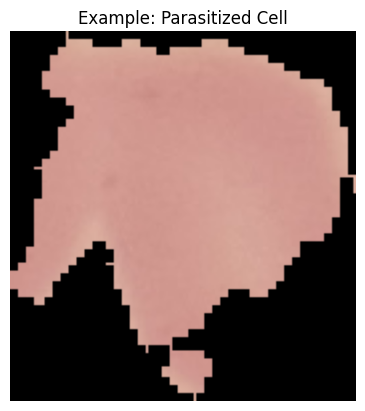

In [5]:
# List all images in each category
parasitized = os.listdir('data/raw/cell_images/Parasitized')
uninfected = os.listdir('data/raw/cell_images/Uninfected')

print(f"Number of Parasitized images: {len(parasitized)}")
print(f"Number of Uninfected images: {len(uninfected)}")

# Display an example image from the Parasitized class
img_path = 'data/raw/cell_images/Parasitized/' + parasitized[0]
img = cv2.imread(img_path)

# Convert from BGR (OpenCV default) to RGB for correct plotting
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# SDhow the image
plt.imshow(img_rgb)
plt.title("Example: Parasitized Cell")
plt.axis('off')
plt.show()

## Data Preprocessing and Augmentation
We use Keras' ImageDataGenerator to:
1.   Normalize pixel values (rescale from 0-255 to 0-1)
2.   Perform real-time data augmentation to improve generalization
3.   Split data into training (80%) and validation (20%)








In [6]:
DATA_SET_PATH = 'data/raw/clean_cell_images'
# Training data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    rotation_range=20,        # Randomly rotate images by up to 20 degrees
    width_shift_range=0.1,    # Shift images horizontally by up to 10%
    height_shift_range=0.1,   # Shift images vertically by up to 10%
    shear_range=0.2,          # Shear transformations
    zoom_range=0.1,           # Zoom in/out randomly
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest',      # Fill in new pixels after transformations
    validation_split=0.2      # Reserve 20% of data for validation
)

# Validation Data Generator
val_datagen = ImageDataGenerator(
    rescale=1./255,           # Only normalize pixel values for validation
    validation_split=0.2
)

# Create Training Dataset Generator
train = train_datagen.flow_from_directory(
    CLEAN_DIR, # Path to dataset
    target_size=(128,128),                    # Resize all images to 128x128 pixels
    batch_size=32,                            # Number of images per batch
    class_mode='binary',                      # Binary classification: Parasitized vs Uninfected
    subset='training',                        # Uses 80% of images for training
    shuffle=True                              # Shuffle images each epoch
)

# Create Validation Dataset Generator
val = val_datagen.flow_from_directory(
    CLEAN_DIR,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation',                      # Uses 20% of images for validation
    shuffle=False                             # No need to shuffle for validation
    )

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


## Baseline Model: Custom CNN
- Build
- Train
- Evaluate
- Save metrics

### Build and Train the CNN Model
This section creates a simple Convolutional Neural Network (CNN) to classify malaria-infected vs uninfected cells. EarlyStopping is used to prevent overfitting.

In [7]:
# Early Stopping Callback
early_stop = EarlyStopping(
    monitor='val_loss',         # Monitor the validation loss
    patience=3,                 # Stop training if val_loss does not improve for 3 epochs
    restore_best_weights=True   # Restore model weights from the epoch with the best val_loss
)

# Build the CNN Model
model = Sequential([
    # 1st Convolutional Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2), # Downsample feature maps by 2x2

    # 2nd Convolutional Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten to 1D vector for Dense layers
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.5),     # Dropout to prevent overfitting

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the Model
model.compile(
    optimizer='adam',           # Adaptive optimizer
    loss='binary_crossentropy', # Binary classification loss
    metrics=['accuracy']        # Track accuracy during training
)

# Train the Model
history = model.fit(
    train,                  # Training data generator
    validation_data=val,    # Validation data generator
    epochs=30,              # Max number of epochs
    callbacks=[early_stop]  # Stop early if validation loss stops improving
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 106s 146ms/step - accuracy: 0.6562 - loss: 0.6233 - val_accuracy: 0.9240 - val_loss: 0.2501
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9111 - loss: 0.2688 - val_accuracy: 0.9332 - val_loss: 0.2081
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9287 - loss: 0.2296 - val_accuracy: 0.9256 - val_loss: 0.2309
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9185 - loss: 0.2382 - val_accuracy: 0.9225 - val_loss: 0.3093
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9273 - loss: 0.2167 - val_accuracy: 0.9356 - val_loss: 0.1764
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9314 - loss: 0.2002 - val_accuracy: 0.9374 - val_loss: 0.1767
Epoch 7/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9331 - loss: 0.1981 - val_accuracy: 0.9390 - val_loss: 0.1670
Epoch 8/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9306 -

### Model Evaluation and Visualization
Evaluate the trained CNN on the validation set.
Generate confusion matrix, classification report, and accuracy/loss plots.

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9266 - loss: 0.1739
Validation Accuracy: 0.9368
Validation Loss: 0.1636


173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step


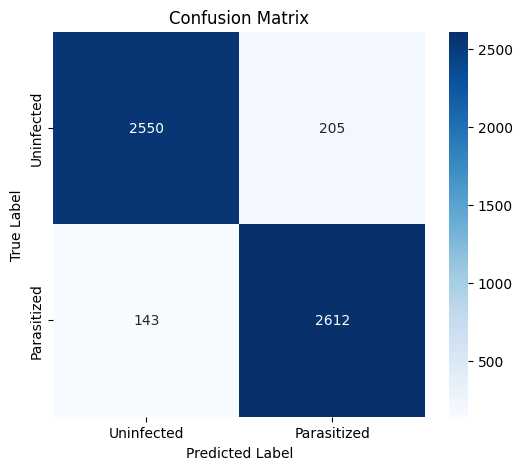

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.95      0.93      0.94      2755
 Parasitized       0.93      0.95      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510



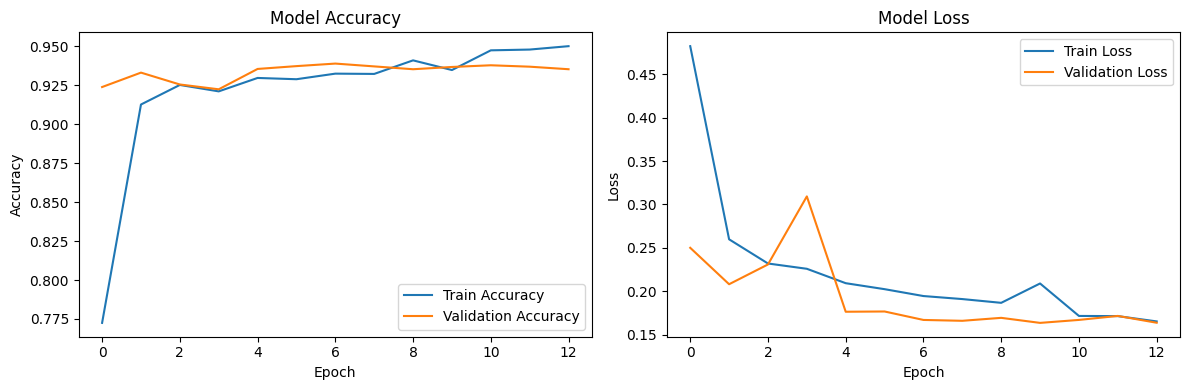

In [8]:
# Evaluate Model on Validation Data
val_loss, val_acc = model.evaluate(val)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print("\n")

# Predict on Validation Data
# model.predict returns probabilities (0 to 1)
y_pred_probs = model.predict(val, steps=len(val))
y_pred = (y_pred_probs > 0.5).astype("int32").ravel() # Convert probabilities to 0 or 1

# True labels from the validation generator
y_true = val.classes

# Confusion Matrix
cm_custom = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_custom, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Uninfected','Parasitized'],
    yticklabels=['Uninfected','Parasitized']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Uninfected','Parasitized']))

# Plot Training History
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [11]:
from google.colab import files

# Save the baseline CNN model
model.save('custom_cnn.keras')
print('Successfully saved model!')

# Download the saved model to your local machine
files.download('custom_cnn.keras')

# Save the model's weights
model.save_weights("custom_cnn_weights_only.weights.h5")
print("Saved the Custom CNN model's weights.")

# Download the saved model weights to your local machine
files.download('custom_cnn_weights_only.weights.h5')

# Save confusion matrices
np.save("custom_cnn_cm.npy", cm_custom)

Successfully saved model!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved the Custom CNN model's weights.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>